# Estimating Counts

#### The Train Problem

A railroad number its locomotives in  order 1...N. One day you see a locomotive with number 60. Estimate how many locomotives the railroad has. 

In [1]:
import numpy as np
from empiricaldist import Pmf

hypos = np.arange(1, 1001)
prior = Pmf(1, hypos)

In [2]:
def update_train(pmf, data):
    hypos = pmf.qs
    likelihood = 1 / hypos
    impossible = (data > hypos)
    likelihood[impossible] = 0
    pmf *= likelihood
    pmf.normalize()

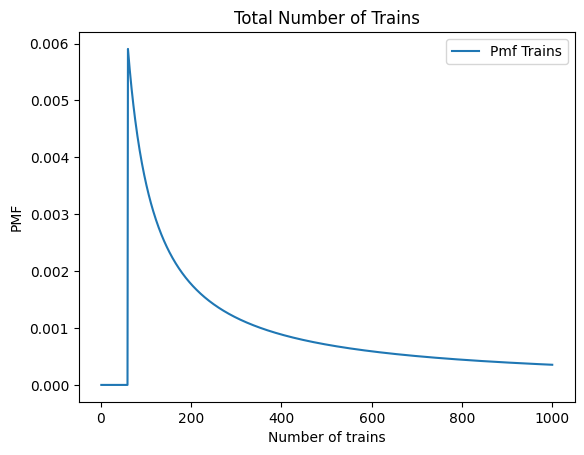

In [7]:
data = 60
posterior = prior.copy()
update_train(posterior, data)

import matplotlib.pyplot as plt

posterior.plot(label = 'Pmf Trains')
plt.xlabel('Number of trains')
plt.ylabel('PMF')
plt.title('Total Number of Trains')
plt.legend()
plt.show()

In [9]:
posterior.max_prob()

np.int64(60)

So, if you had to guess, guessing 60 would maximize your chances of getting the exact right answer. However, maybe the goal is to find the mean of the posterior distribution. 

$$ mean = \sum_i p_i q_i $$

In [12]:
print(np.sum(posterior.ps * posterior.qs))

# or

print(posterior.mean())

333.41989326370776
333.41989326370776


#### Sensitivity to the Prior

Observe the changes in the distribution as we change the inputs to the prior and the data:

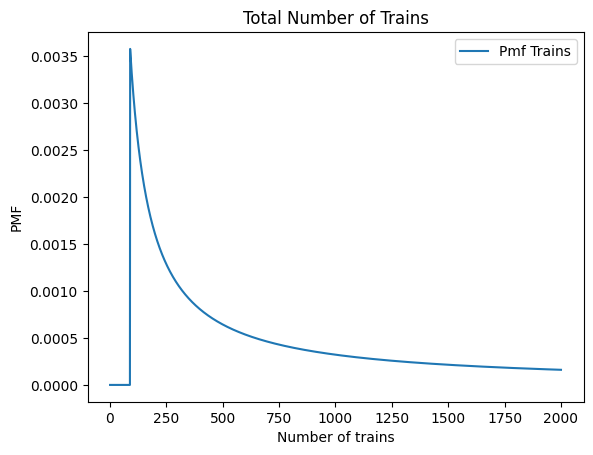

In [16]:
hypos = np.arange(1, 2001) # increase the prior
prior = Pmf(1, hypos)

data = 90
posterior = prior.copy()
update_train(posterior, data)

import matplotlib.pyplot as plt

posterior.plot(label = 'Pmf Trains')
plt.xlabel('Number of trains')
plt.ylabel('PMF')
plt.title('Total Number of Trains')
plt.legend()
plt.show()

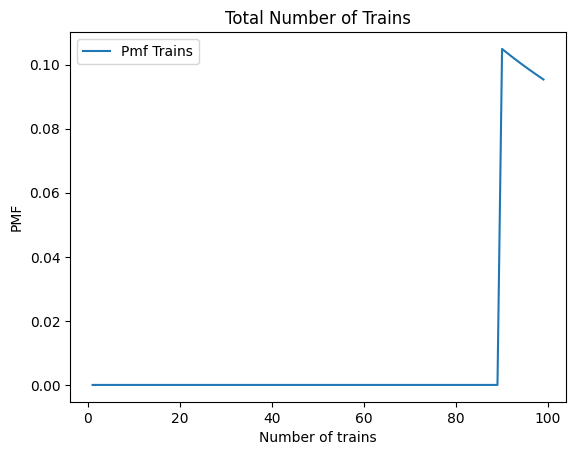

In [17]:
hypos = np.arange(1, 100) #      decrease the prior
prior = Pmf(1, hypos)

data = 90 #         increase the data
posterior = prior.copy()
update_train(posterior, data)

import matplotlib.pyplot as plt

posterior.plot(label = 'Pmf Trains')
plt.xlabel('Number of trains')
plt.ylabel('PMF')
plt.title('Total Number of Trains')
plt.legend()
plt.show()

#### Power Law Prior

In an effort to find a better prior, we can make some assumptions about the locomotive industry as a whole. A new prior might be based on the idea that the size of a railroad company might follow a power law (as some economists suggest many industries do). Mathematically, this means that the number of companies of a given size 'N' is proportional to (1/N)^a where 'a' is a parameter that is often near 1. 

In [27]:
# construct a power law prior
alpha = 1.0
ps = hypos **(-alpha)
power = Pmf(ps, hypos, name = 'power law')
power.normalize()

np.float64(7.485470860550345)

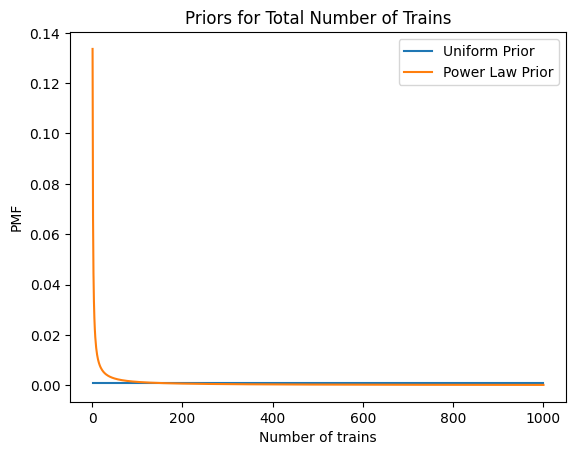

In [29]:
# uniform prior for comparison
hypos = np.arange(1, 1001)
uniform = Pmf(1, hypos, name = 'uniform')
uniform.normalize()

uniform.plot(label = 'Uniform Prior')
power.plot(label = 'Power Law Prior')
plt.xlabel('Number of trains')
plt.ylabel('PMF')
plt.title('Priors for Total Number of Trains')
plt.legend()
plt.show()

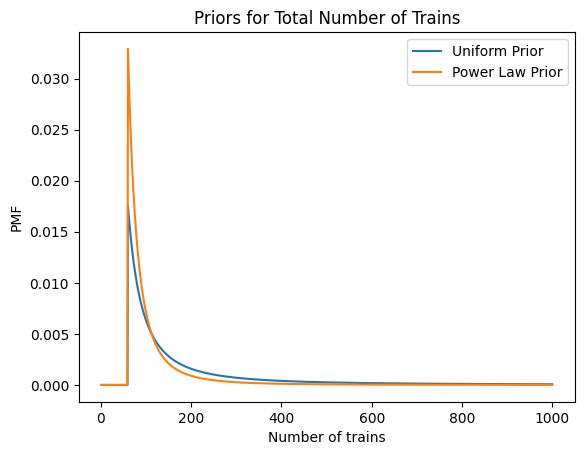

In [31]:
dataset = [60]
update_train(uniform, dataset)
update_train(power, dataset)

uniform.plot(label = 'Uniform Prior')
power.plot(label = 'Power Law Prior')
plt.xlabel('Number of trains')
plt.ylabel('PMF')
plt.title('Priors for Total Number of Trains')
plt.legend()
plt.show()

The power law prior helps assign less probability to higher values that a less informed prior would. 

#### Credible Intervals

This is a new tool to summarize a posterior distribution as an alternative to the MAP (highest posterior probability) or the mean. 

In [32]:
# compute prob that a company has less that or equal to 100 trains

power.prob_le(100)

np.float64(0.6517781143515997)

In [33]:
def quantile(pmf, prob):
    total = 0
    for q, p in pmf.items():
        total += p
        if total >= prob:
            return q
        return np.nan

In [34]:
quantile(power, 0.5)

nan

In [35]:
power.quantile([0.05, 0.95])

array([ 61., 258.])